In [189]:
import numpy as np
import pandas as pd
import seaborn as sns

In [190]:
df=pd.read_csv("student_performance_dataset.csv")

In [191]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [192]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


# EDA For better Performance of Models

## Checking which columns have better linear relation with target

<Axes: >

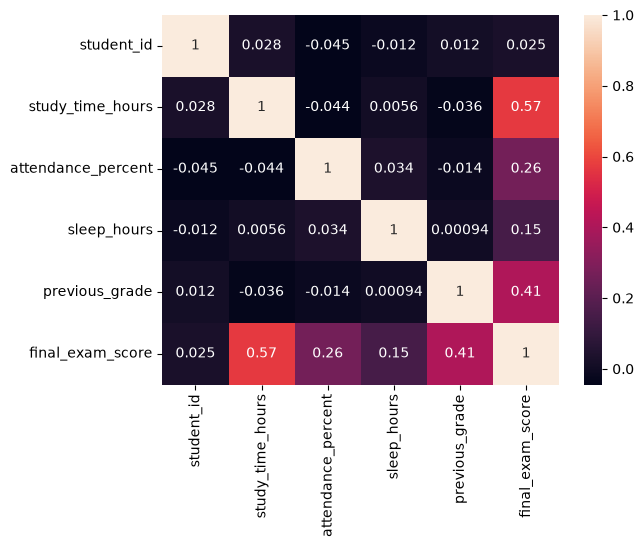

In [194]:
# Checking for numerical columns
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

<Axes: xlabel='sleep_hours', ylabel='final_exam_score'>

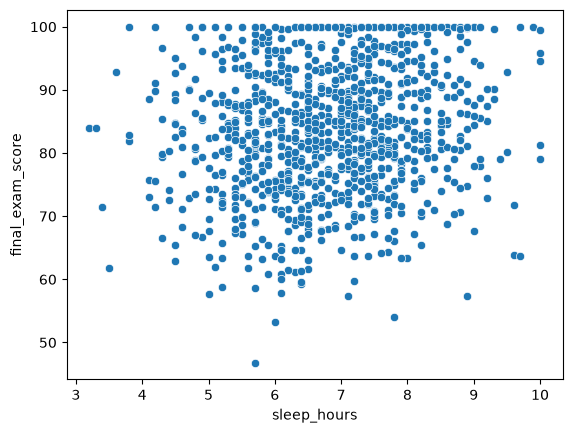

In [195]:
sns.scatterplot(df,x="sleep_hours",y="final_exam_score")

<Axes: xlabel='attendance_percent', ylabel='final_exam_score'>

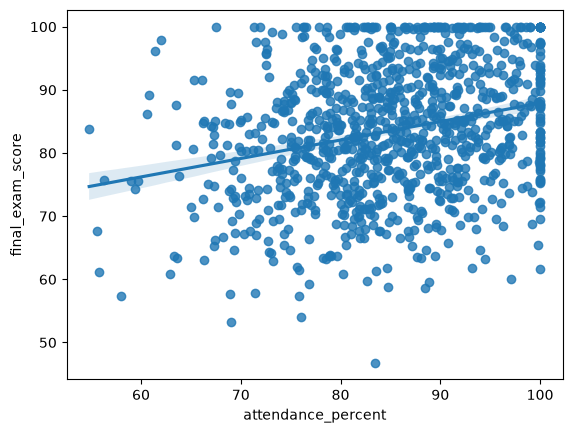

In [196]:
sns.regplot(df,x="attendance_percent",y="final_exam_score")
# Can be used with other Columns

<Axes: xlabel='gender', ylabel='final_exam_score'>

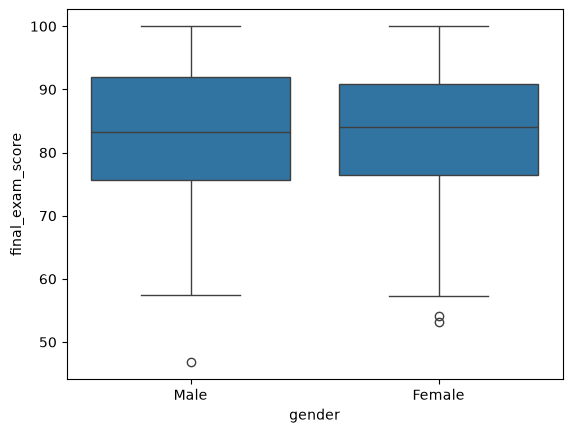

In [197]:
sns.boxplot(df,x="gender",y="final_exam_score")

<Axes: xlabel='gender', ylabel='final_exam_score'>

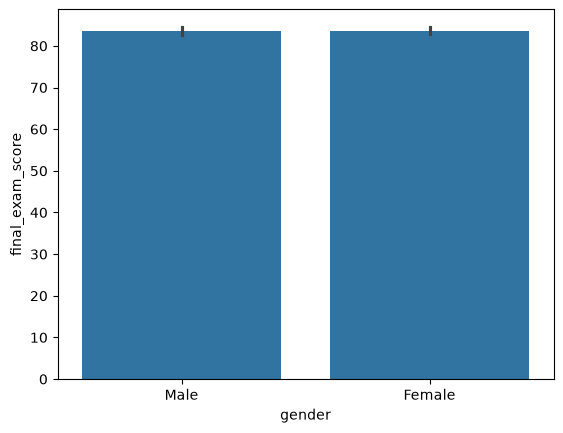

In [198]:
sns.barplot(df,x="gender",y="final_exam_score")
# Not much better for linear model

<Axes: xlabel='parental_education', ylabel='final_exam_score'>

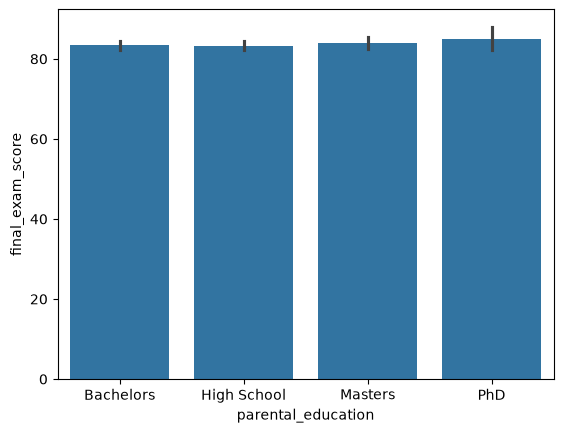

In [199]:
sns.barplot(df,x="parental_education",y="final_exam_score")
# it is not showing much change and definetly not a linear change so i think we either can use it with a One hot encoder or leave it entierly 

<Axes: xlabel='internet_access', ylabel='final_exam_score'>

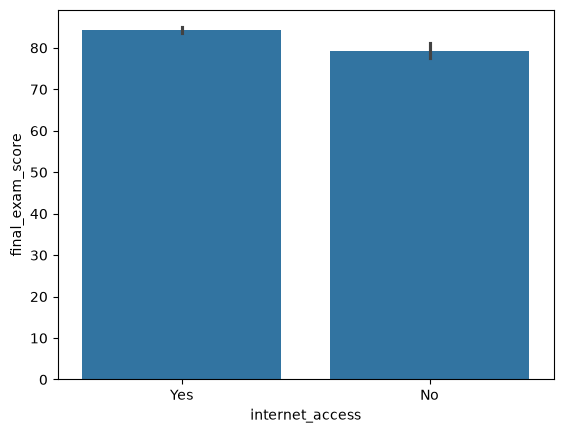

In [200]:
sns.barplot(df,x="internet_access",y="final_exam_score")
# Good for linear model

<Axes: xlabel='extracurricular_activities', ylabel='final_exam_score'>

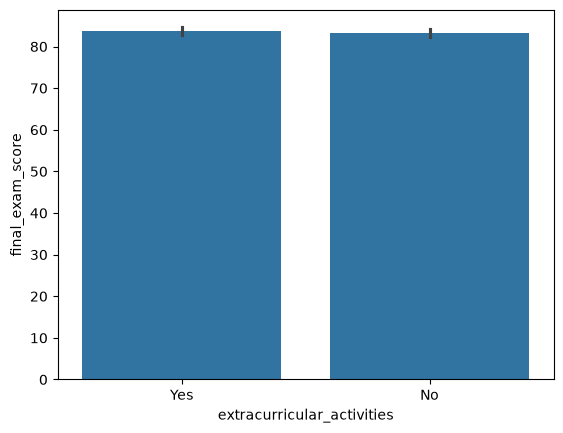

In [201]:
sns.barplot(df,x="extracurricular_activities",y="final_exam_score")
# Not much difference between the two categories

<Axes: xlabel='part_time_job', ylabel='final_exam_score'>

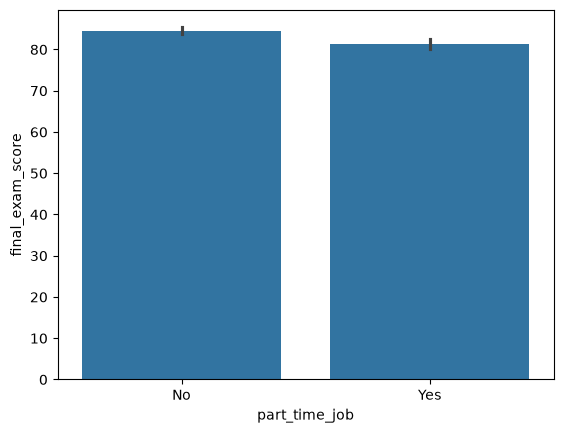

In [202]:
sns.barplot(df,x="part_time_job",y="final_exam_score")
# Good enough to be used for model training 

# Creating PrePorcessing pipeline

In [203]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression,LogisticRegression


In [204]:
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='str')

In [205]:
numCol=["study_time_hours","attendance_percent","sleep_hours","previous_grade"]
NominalCatCol=["internet_access","part_time_job"]


In [206]:
numPipeline=Pipeline([("Scaler",StandardScaler())])
NominalPipeline=Pipeline([("Encode",OneHotEncoder(drop="first"))])

# Task1

In [207]:
PreProcessing=ColumnTransformer([("numPipeline",numPipeline,numCol),("NominalFeature",NominalPipeline,NominalCatCol)],remainder="drop")


In [208]:
X=df.drop(columns="final_exam_score")
Y=df["final_exam_score"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [209]:
LinearRPipeline=Pipeline([("Preprocessing",PreProcessing),("Model",LinearRegression())])
LinearRPipeline.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['student_id','gender','study_time_hours',...,'part_time_job', 'previous_grade','final_grade']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numPipeline', ...), ('NominalFeature', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

<Axes: ylabel='final_exam_score'>

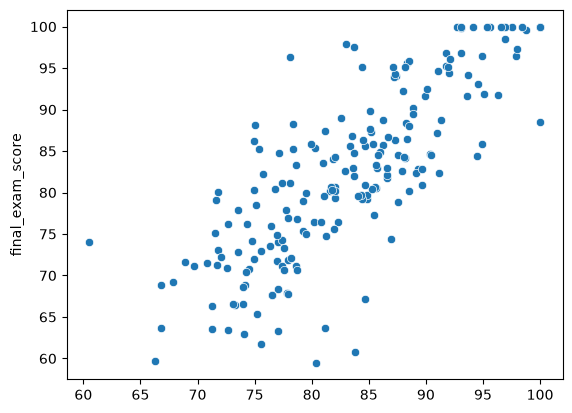

In [210]:
LI_Y_pred = np.clip(LinearRPipeline.predict(X_test), 0, 100) # So the values don't go above 100
sns.scatterplot(x=LI_Y_pred,y=Y_test)

# Task2

In [211]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error

In [212]:
mae=mean_absolute_error(LI_Y_pred,Y_test)
mse=mean_squared_error(LI_Y_pred,Y_test)
rmse=root_mean_squared_error(LI_Y_pred,Y_test)
print(f"{mae}:Mean Absolute Error:Tells us the Mean of the Difference Between Predicted and Actual values")
print(f"{mse}:Mean Square Error:Tells us the Mean of the Square of Difference Between Predicted and Actual values. Used when Large Errors are More problamatic than more small errors.")
print(f"{rmse}:Root Mean Square Error:It is the root of mean Square Error , as Mean Square Error gives us a Squared value, it just gives us its root.")

4.884589150737326:Mean Absolute Error:Tells us the Mean of the Difference Between Predicted and Actual values
40.16157132313018:Mean Square Error:Tells us the Mean of the Square of Difference Between Predicted and Actual values. Used when Large Errors are More problamatic than more small errors.
6.3373157821849295:Root Mean Square Error:It is the root of mean Square Error , as Mean Square Error gives us a Squared value, it just gives us its root.


# Part3-Classification Algorithems 

## Task 3

In [213]:
# We have the Target Column for classification as final_grade but it do has a hairarchy so maybe using an ordinal model will be much better,or using a regression model with conversion of marks to grade
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,precision_score,recall_score

In [214]:
LogisticPipeline=Pipeline([("Preprocessing",PreProcessing),("Model",LogisticRegression())])
X=df.drop(columns=["final_grade"])
Y=df["final_grade"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=32,stratify=Y) #Stratify makes equal division of categories in Y between training and testing data

In [215]:
LogisticPipeline.fit(X_train,Y_train)
LR_Y_pred=LogisticPipeline.predict(X_test)
LRacc=accuracy_score(Y_test,LR_Y_pred)
LRpre=precision_score(Y_test,LR_Y_pred,average="weighted")
LRrecall=recall_score(Y_test,LR_Y_pred,average="weighted")
LRF1=f1_score(Y_test,LR_Y_pred,average="weighted")
print(f"Accuracy:{LRacc}")
print(f"Precission:{LRpre}")
print(f"Recall:{LRrecall}")
print(f"F1 score:{LRF1}")

Accuracy:0.615
Precission:0.6294810823205687
Recall:0.615
F1 score:0.6137681940700809


c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [216]:
Y_test.value_counts()
#can be a reason for bad accuracy

final_grade
B    71
A    57
C    52
D    18
F     2
Name: count, dtype: int64

In [217]:
print(f"Actual value of First 10 columns  : {np.array(df["final_grade"].iloc[0:10])}")
print(f"Predicted value of First 10 Columns:{LogisticPipeline.predict(df.iloc[0:10])}")#Accurac was shown 2 box above.

Actual value of First 10 columns  : ['A' 'A' 'A' 'B' 'D' 'B' 'D' 'B' 'B' 'C']
Predicted value of First 10 Columns:['A' 'A' 'A' 'B' 'C' 'B' 'C' 'A' 'B' 'C']


## Task4

In [218]:
#I Think the features used for linear model are good enough for NB as well as other features do not show much variations so they will be like noise
#It can be that the features i am using right now are skewed so if i will have to decide on a model then i will check the skewness but currently for the assignment i will have to train it with NB and target is alredy skewed
BayesPipeline=Pipeline([("Preprocessing",PreProcessing),("Model",GaussianNB())])
BayesPipeline.fit(X_train,Y_train)
NB_Y_pred=BayesPipeline.predict(X_test)
print(f"Actual value of First 10 columns :{np.array(df["final_grade"].iloc[0:10])}")
print(f"NB Prediction of First 10 Columns:{BayesPipeline.predict(df.iloc[0:10])}")
print(f"LR Prediction of First 10 Columns:{LogisticPipeline.predict(df.iloc[0:10])}")
#as the target is heively skewed it will have problem in predecting F and D

Actual value of First 10 columns :['A' 'A' 'A' 'B' 'D' 'B' 'D' 'B' 'B' 'C']
NB Prediction of First 10 Columns:['A' 'A' 'A' 'B' 'C' 'B' 'C' 'A' 'B' 'B']
LR Prediction of First 10 Columns:['A' 'A' 'A' 'B' 'C' 'B' 'C' 'A' 'B' 'C']


In [219]:
NBacc=accuracy_score(Y_test,NB_Y_pred)
NBpre=precision_score(Y_test,NB_Y_pred,average="weighted")
NBrecall=recall_score(Y_test,NB_Y_pred,average="weighted")
NBF1=f1_score(Y_test,NB_Y_pred,average="weighted")
print(f"Accuracy:{NBacc}")
print(f"Precission:{NBpre}")
print(f"Recall:{NBrecall}")
print(f"F1 Score:{NBF1}")

Accuracy:0.51
Precission:0.5900510671525246
Recall:0.51
F1 Score:0.49977951715803376


c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Task5

In [220]:
KNNPipeline1=Pipeline([("PreProcessing",PreProcessing),("Model",KNeighborsClassifier(n_neighbors=7,metric="minkowski",p=2))])
KNNPipeline2=Pipeline([("PreProcessing",PreProcessing),("Model",KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2))])
KNNPipeline3=Pipeline([("PreProcessing",PreProcessing),("Model",KNeighborsClassifier(n_neighbors=9,metric="minkowski",p=2))])
KNNPipeline1.fit(X_train,Y_train)
KNNPipeline2.fit(X_train,Y_train)
KNNPipeline3.fit(X_train,Y_train)
KNN_Y_pred1=KNNPipeline1.predict(X_test)
KNN_Y_pred2=KNNPipeline2.predict(X_test)
KNN_Y_pred3=KNNPipeline3.predict(X_test)
Accuracy1=accuracy_score(Y_test,KNN_Y_pred1)
Accuracy2=accuracy_score(Y_test,KNN_Y_pred2)
Accuracy3=accuracy_score(Y_test,KNN_Y_pred3)
print(Accuracy1)
print(Accuracy2)
print(Accuracy3)
# Choosing k=9 one model

0.49
0.5
0.53


In [221]:
KNNacc=accuracy_score(Y_test,KNN_Y_pred3)
KNNpre=precision_score(Y_test,KNN_Y_pred3,average="weighted")
KNNrecall=recall_score(Y_test,KNN_Y_pred3,average="weighted")
KNNF1=f1_score(Y_test,KNN_Y_pred1,average="weighted")
print(f"Accuracy:{KNNacc}")
print(f"Precission:{KNNpre}")
print(f"Recall:{KNNrecall}")
print(f"F1 Score:{KNNF1}")

Accuracy:0.53
Precission:0.5377767353939861
Recall:0.53
F1 Score:0.4743017905076547


c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Task 6

In [222]:
#Accuracy Precision Recall and f1 score are alredy Displayed in task 7
LRreport=classification_report(Y_test,LR_Y_pred)
print(LRreport)

              precision    recall  f1-score   support

           A       0.78      0.67      0.72        57
           B       0.54      0.68      0.60        71
           C       0.56      0.56      0.56        52
           D       0.80      0.44      0.57        18
           F       0.00      0.00      0.00         2

    accuracy                           0.61       200
   macro avg       0.53      0.47      0.49       200
weighted avg       0.63      0.61      0.61       200



c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [223]:
NBreport=classification_report(Y_test,NB_Y_pred)
print(NBreport)
#Naive Bayes is completely not predecting F

              precision    recall  f1-score   support

           A       0.85      0.51      0.64        57
           B       0.46      0.73      0.57        71
           C       0.36      0.35      0.35        52
           D       1.00      0.17      0.29        18
           F       0.00      0.00      0.00         2

    accuracy                           0.51       200
   macro avg       0.53      0.35      0.37       200
weighted avg       0.59      0.51      0.50       200



c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [224]:
KNNreport=classification_report(Y_test,KNN_Y_pred3)
print(KNNreport)

              precision    recall  f1-score   support

           A       0.70      0.65      0.67        57
           B       0.47      0.65      0.54        71
           C       0.45      0.38      0.42        52
           D       0.60      0.17      0.26        18
           F       0.00      0.00      0.00         2

    accuracy                           0.53       200
   macro avg       0.44      0.37      0.38       200
weighted avg       0.54      0.53      0.52       200



c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\satya\anaconda3\envs\pvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [225]:
LRConfusion=confusion_matrix(Y_test,LR_Y_pred)
print(LRConfusion)

[[38 18  1  0  0]
 [11 48 12  0  0]
 [ 0 22 29  1  0]
 [ 0  1  9  8  0]
 [ 0  0  1  1  0]]


In [226]:
NBConfusion=confusion_matrix(Y_test,NB_Y_pred)
print(NBConfusion)

[[29 23  5  0  0]
 [ 5 52 14  0  0]
 [ 0 34 18  0  0]
 [ 0  4 11  3  0]
 [ 0  0  2  0  0]]


In [227]:
KNNConfusion=confusion_matrix(Y_test,KNN_Y_pred3)
print(KNNConfusion)

[[37 19  1  0  0]
 [15 46 10  0  0]
 [ 1 30 20  1  0]
 [ 0  3 12  3  0]
 [ 0  0  1  1  0]]


# Task7-Over Fitting and under Fitting

### I am uning knn for over fitting and Under fitting

In [228]:
OverFit=Pipeline([("PreProcessing",PreProcessing),("Model",KNeighborsClassifier(n_neighbors=1,metric="minkowski",p=2))])
OverFit.fit(X_train,Y_train)
UnderFit=Pipeline([("PreProcessing",PreProcessing),("Model",KNeighborsClassifier(n_neighbors=500,metric="minkowski",p=2))])
UnderFit.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('PreProcessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['A','B','C','D','F']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['student_id','gender','study_time_hours',...,'part_time_job', 'previous_grade','final_exam_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numPipeline', ...), ('NominalFeature', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defau

In [229]:
#For OverFit
Over_pred=OverFit.predict(X_train)
Over_pred_test=OverFit.predict(X_test)
print(f"Accuracy on Training Data:{accuracy_score(Y_train,Over_pred)}")
print(f"Accuracy on Testing Data:{accuracy_score(Y_test,Over_pred_test)}")

Accuracy on Training Data:1.0
Accuracy on Testing Data:0.435


In [230]:
#For UnderFit
Under_pred=UnderFit.predict(X_train)
Under_pred_test=UnderFit.predict(X_test)
print(f"Accuracy on Training Data:{accuracy_score(Y_train,Under_pred)}")
print(f"Accuracy on testing Data:{accuracy_score(Y_test,Under_pred_test)}")

Accuracy on Training Data:0.39625
Accuracy on testing Data:0.375


### The Training accuracy of An overfit model is very good (a full 100%) but it performs worst when tested(on unseen data)

### Both the training and test accuracy of an underfit(badly trained) model are worst 

## Task 8

##### Bias:The Error values we get when we run The model on the training data , eg:Overfitted data has 0 bias(Perfect result for training data) but gets high bias on under fitted data only getting 39.6% accuracy

#### Variance: The Error values a model gets on testing/unseen data , both over fitted and underfitted models give high variance.

#### Over fitted models have very low bias but high variance

#### Under fitted models have high bias and high variance

#### Preventing overfitting is primeraly training our model to learn the underlieng patterns in the data rather that memorizing all the inputs and outputs ,this can primerly be done of the following ways:
##### i)Training on bigger data
##### ii)Combining predections from different models(Eg:Random Forest)
##### iii)Choosing better HyperParameters (Not using k=1 for KNN Model)
##### iv)Earlier Stopping for itterative models like Logistic Regression